In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.analyses import (decoding_crossmodal_stats,
                                test_decoding_above_chance)
from multipred.plotting import (barplot_morey, plot_crossmodal,
                                plot_decoding_modalities,
                                plot_decoding_modalities_attention,
                                plot_decoding_pred)

                                #plot_decoding_nvoxels)

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across modalities

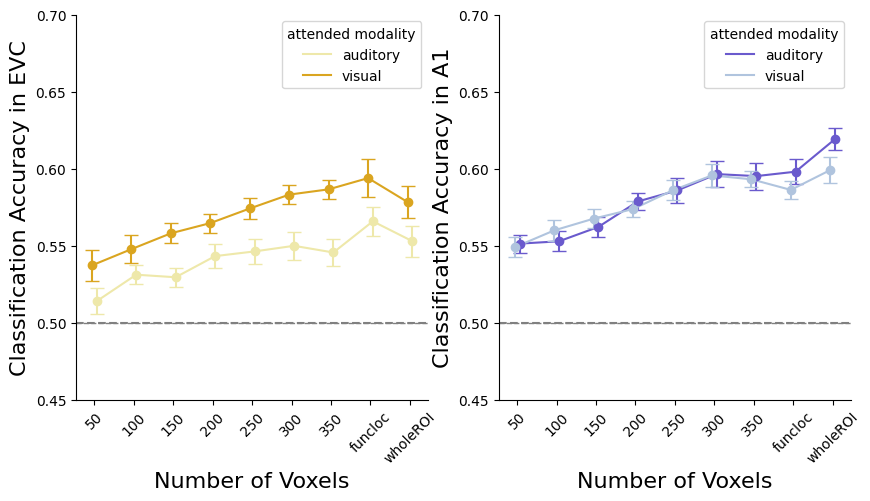

In [3]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_modalities_attention(DATA_PATH, n_voxels_list, error_type="ws")
df_decoding_abovechance = test_decoding_above_chance(df_allROIs, n_voxels_list) # create a dataframe with results of a binomial test

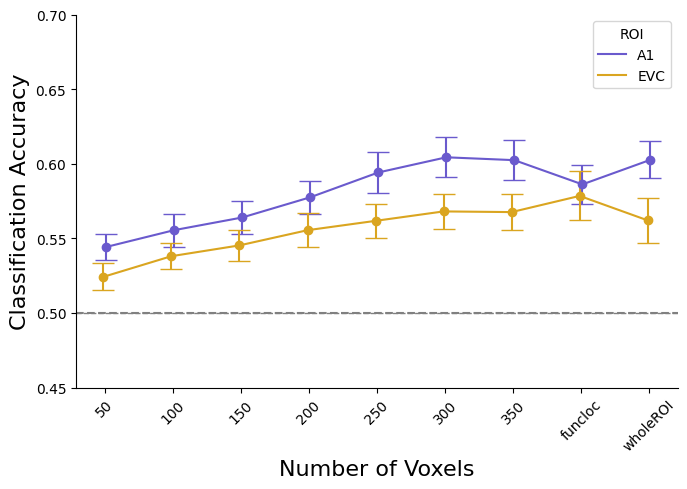


Summary of decoding accuracy statistics:
 n_voxels_label ROI  n_subjects  accuracy  t_value  p_value
             50 EVC          24    0.5242   2.6457   0.0144
             50  A1          24    0.5442   4.9531   0.0001
            100 EVC          24    0.5380   4.3604   0.0002
            100  A1          24    0.5555   5.0543   0.0001
            150 EVC          23    0.5453   4.4613   0.0002
            150  A1          23    0.5639   5.6240   0.0000
            200 EVC          23    0.5554   4.9510   0.0001
            200  A1          23    0.5775   6.9884   0.0000
            250 EVC          23    0.5617   5.5156   0.0000
            250  A1          23    0.5941   7.0055   0.0000
            300 EVC          23    0.5680   5.9351   0.0000
            300  A1          23    0.6043   7.7909   0.0000
            350 EVC          23    0.5676   5.7108   0.0000
            350  A1          23    0.6024   7.5192   0.0000
            400 EVC          24    0.5784   4.7737   0.000

In [3]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]

df_all, df_stats = plot_decoding_modalities(DATA_PATH, n_voxels_list)

# Show the summary of decoding results
print("\nSummary of decoding accuracy statistics:")
print(df_stats.round(4).to_string(index=False))

## Analyze Attention * Prediction for specific ROI size

In [4]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
# df["prob_predictions"] = np.where(df["prob_0"] < 0.5, 45, 135)
# df["prob_correct"] = np.where(
#     df["labels"] == df["prob_predictions"], 1, 0
# )  # 1 if prob prediction is correct, 0 if not


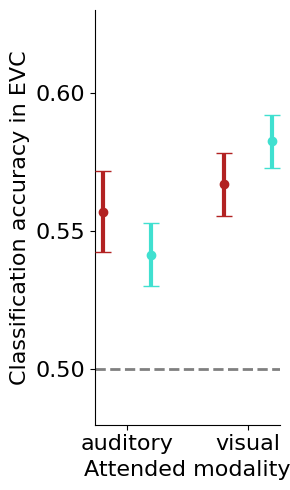

In [5]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [5]:
df.groupby(["v_pred"])[y].mean()

v_pred
0    0.561987
1    0.562046
Name: correct, dtype: float64

In [6]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [7]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="visual"], alternative="less", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,-1.251142,24.0,less,0.111471,0.847,-0.169413


In [8]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="auditory"], alternative="greater", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,0.837512,24.0,greater,0.205284,0.579,0.174591


## Multimodal analyses

### Check interaction across ROI sizes

#### Visual attended

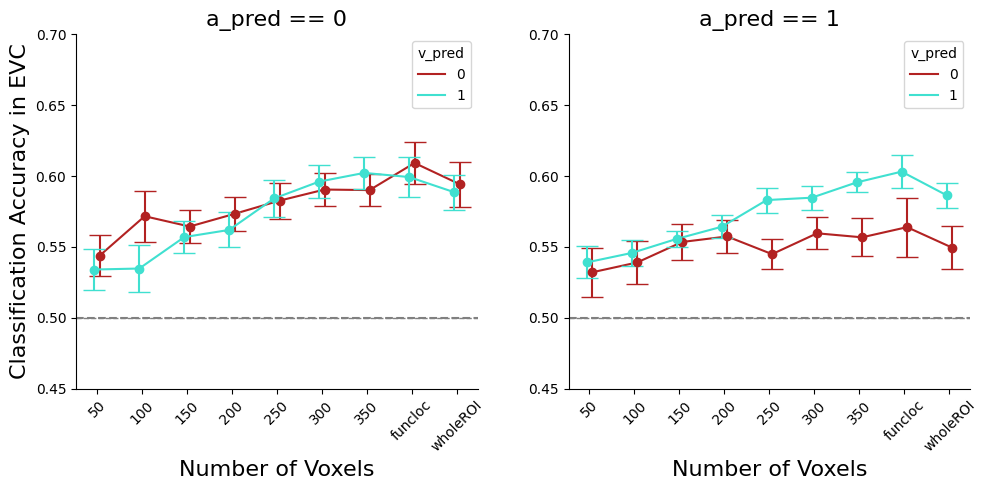

In [6]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
ROI = "EVC"
hue = "v_pred"
col = "a_pred"
attended_modality = "visual"
palette = ["firebrick", "turquoise"]
df_attended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="ws", save_fig=False)


Compute stats for each ROI size, and save them

In [10]:
factors = ("a_pred", "v_pred")
alternative = "less" # sharpening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_stats(df_attended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = [
    "50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"
]

# Rename columns
anova_df = anova_df.reset_index().rename(columns={
    "n_voxels_label": "ROI size"
})
ttest_df = ttest_df.reset_index().rename(columns={
    "n_voxels_label": "ROI size",
    "a_pred": "auditory EXP"
})

# Set ROI size as ordered categorical
anova_df["ROI size"] = pd.Categorical(anova_df["ROI size"], categories=roi_order, ordered=True)
ttest_df["ROI size"] = pd.Categorical(ttest_df["ROI size"], categories=roi_order, ordered=True)

# Sort values
anova_df = anova_df.sort_values(["ROI size", "Source"]).set_index(["ROI size", "Source"])
ttest_df = ttest_df.sort_values(["ROI size", "auditory EXP", "Contrast"]).set_index(["ROI size", "auditory EXP", "Contrast"])

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/v_decoding_attended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/v_decoding_attended_ttests.csv", index=False)

#### Auditory attended

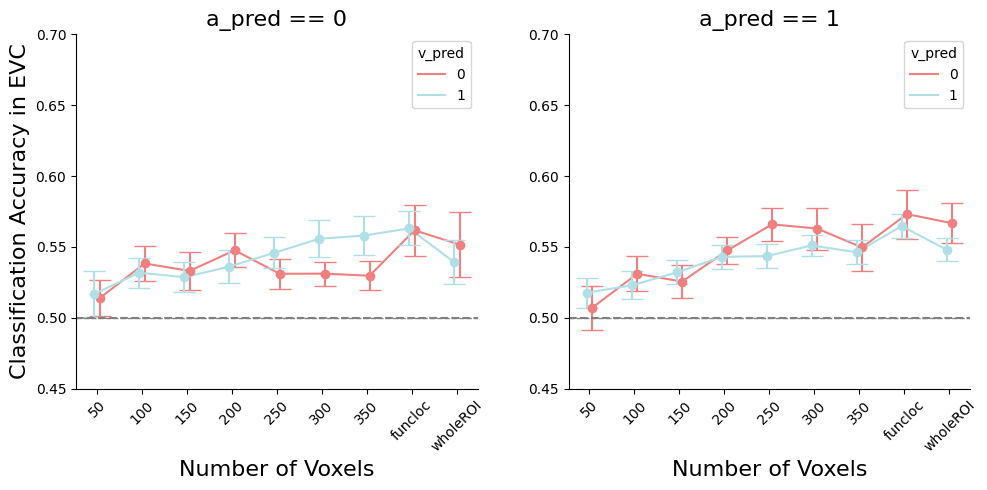

In [11]:
ROI = "EVC"
hue = "v_pred"
col = "a_pred"
attended_modality = "auditory"
palette = ["lightcoral", "powderblue"]
df_unattended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="ws", save_fig=False)

Compute stats for each ROI size, and save them

In [12]:
factors = ("a_pred", "v_pred")
alternative = "greater" # dampening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_stats(df_unattended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = [
    "50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"
]

# Rename columns
anova_df = anova_df.reset_index().rename(columns={
    "n_voxels_label": "ROI size"
})
ttest_df = ttest_df.reset_index().rename(columns={
    "n_voxels_label": "ROI size",
    "a_pred": "auditory EXP"
})

# Set ROI size as ordered categorical
anova_df["ROI size"] = pd.Categorical(anova_df["ROI size"], categories=roi_order, ordered=True)
ttest_df["ROI size"] = pd.Categorical(ttest_df["ROI size"], categories=roi_order, ordered=True)

# Sort values
anova_df = anova_df.sort_values(["ROI size", "Source"]).set_index(["ROI size", "Source"])
ttest_df = ttest_df.sort_values(["ROI size", "auditory EXP", "Contrast"]).set_index(["ROI size", "auditory EXP", "Contrast"])

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/v_decoding_unattended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/v_decoding_unattended_ttests.csv", index=False)

### Check cross-modal effect for a specific ROI size

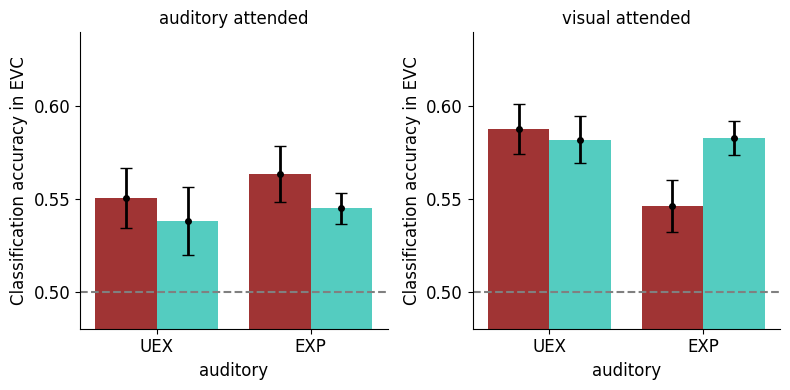

In [3]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[y].mean()

plot_crossmodal(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)